# Анализ временного ряда - ВВП Ганы

Задача проанализировать ВВП африканской страны Гана. Для этого предоставлены показатели ВВП Ганы за 62 года. Нам предстоит исследовать временной ряд, изучить его свойства, построить модели и сделать выводы по результатам.

Исходные данные можно скачать по [ссылке](https://lms-cdn.skillfactory.ru/assets/courseware/v1/cf3fb9ca311981f5cc6b6f0a40621388/asset-v1:SkillFactory+DST-3.0+28FEB2021+type@asset+block/ghana_gdp.zip)

# Импорт, загрузка и настройка данных

In [1]:
# Базовые библиотеки
import numpy as np
import pandas as pd

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.figsize'] = (12, 4)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# Машинное обучение
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import pmdarima as pm
from arch import arch_model
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

#Настройки
import warnings
from IPython.display import display
warnings.filterwarnings("ignore")

In [2]:
# Загрузка данных
data = pd.read_csv("data/ghana_gdp.zip", parse_dates=["year"], index_col=["year"])
data.head()

,GDP (current US$)
year,
1960-01-01,1.217087e+09
1961-01-01,0.000000e+00
1962-01-01,1.382353e+09
1963-01-01,1.540616e+09
1964-01-01,1.731092e+09


# Предварительный анализ данных

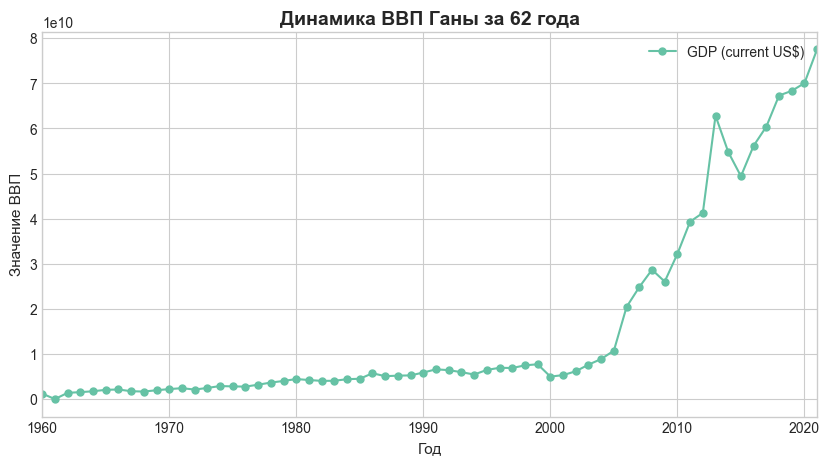

In [3]:
# Визуализируем исходный временной ряд
data.plot(marker='o', markersize=5, figsize=(10, 5))
plt.title('Динамика ВВП Ганы за 62 года', fontsize=14, fontweight='bold')
plt.xlabel('Год', fontsize=11)
plt.ylabel('Значение ВВП', fontsize=11)
plt.show();

На основе построенного графика можно сделать следующие первичные выводы о структуре временного ряда ВВП Ганы:
- Тренд: В ряде присутствует сильный нелинейный тренд общего роста. Примерно до 2000-х годов ВВП рос медленно и линейно, а после 2005 года начался взрывной рост.
- Нестационарность: Из-за сильного изменения среднего значения и дисперсии во времени ряд очевидно нестационарен. 
- Отсутствие внутригодовой сезонности: Данные являются годовыми (каждая точка — один год), поэтому классическая краткосрочная сезонность (например, квартальная или месячная) в них физически отсутствует.
- Влияние внешних факторов: На графике четко видны сильные экономические провалы - падение около 2000 года и резкий провал в районе 2013–2015 годов. Скорее всего связано с внешнеэкономическими компонентами.

In [4]:
# Разделим выборку на тестову и обучающую
train = data.iloc[:-3]
test = data.iloc[-3:]
# Проверим размер выборок
print(f"Размер обучающей выборки (train): {train.shape[0]} лет")
print(f"Размер тестовой выборки (test): {test.shape[0]} года")

Размер обучающей выборки (train): 59 лет
Размер тестовой выборки (test): 3 года


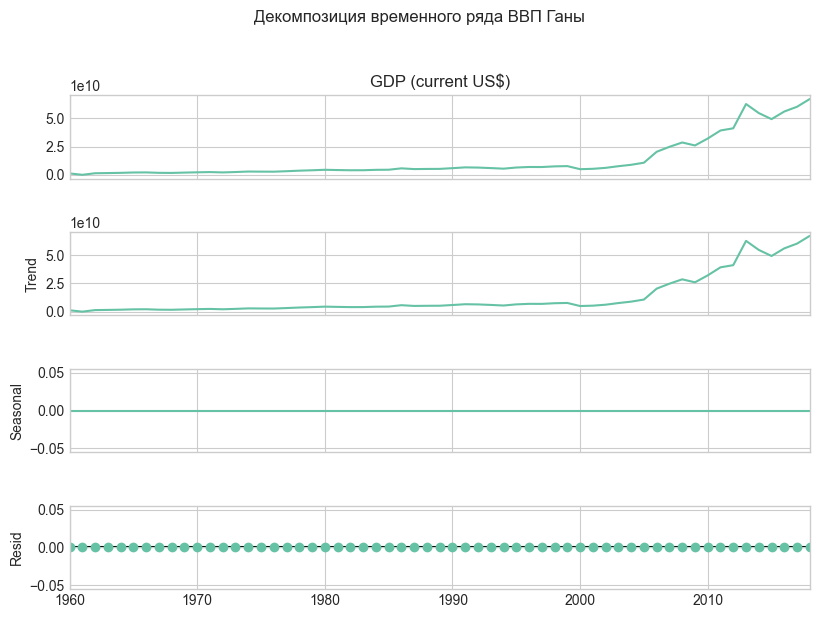

In [5]:
# Декомпозиция ряда на компоненты (тренд, сезонность, остатки)
decomposition = seasonal_decompose(train['GDP (current US$)'], model='additive', period=1)
fig = decomposition.plot()
fig.set_size_inches(8, 6)
plt.suptitle('Декомпозиция временного ряда ВВП Ганы', y=1.05)
plt.show();

График декомпозиции подтверждает сделанные ранее выводы. Компонента тренда полностью повторяет форму исходного ряда, указывая на сильный нелинейный рост. Сезонная составляющая (Seasonal) и остатки (Resid) равны нулю, что математически доказывает полное отсутствие внутригодовой сезонности в годовых данных.

Построим график скользящего среднего. Для построения MA используем метод `rolling()`, который принимает в качестве параметра размер окна.
Для сглаживания выбрано окно в 3 года. В отличие от более широкого окна в 5 лет, оно не срезает важные развороты тренда на конце выборки, и в отличие от окон меньшего размера реально сглаживает случайный шум, сохраняя точную траекторию роста ВВП.

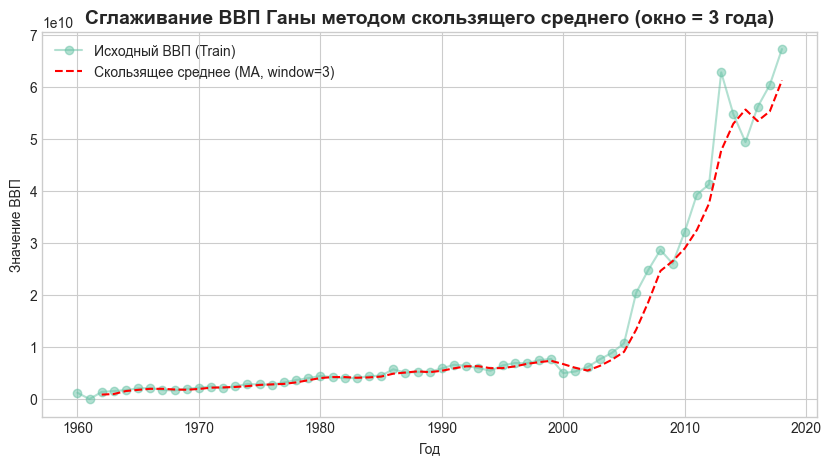

In [6]:
# Построим график скользящего среднего
# Вычисляем скользящее среднее с окном в 3 года
train_ma_5 = train['GDP (current US$)'].rolling(window=3).mean()

# Построение графиков
plt.figure(figsize=(10, 5))
plt.plot(train.index, train['GDP (current US$)'], marker='o', alpha=0.5, label='Исходный ВВП (Train)')
plt.plot(train.index, train_ma_5, color='red', linestyle='--', label='Скользящее среднее (MA, window=3)')

plt.title('Сглаживание ВВП Ганы методом скользящего среднего (окно = 3 года)', fontsize=14, fontweight='bold')
plt.xlabel('Год')
plt.ylabel('Значение ВВП')
plt.legend()
plt.show();

График подтверждает наличие сильного восходящего нелинейного тренда ВВП Ганы. Окно в 3 года эффективно сглаживает случайный шум, минимизирует запаздывание и точно передает все крупные экономические циклы и развороты ряда на финальном участке выборки.

# Исследование стационарности и построение моделей ARIMA

С помощью теста Дики-Фуллера оценим стационарность временного ряда и примем решение о выборе модели ARMA/ARIMA. 

In [7]:
def make_stationary(series, d=0, max_d=3):
    """
    Рекурсивно приводит временной ряд к стационарному виду с помощью дифференцирования.
    
    На каждой итерации вычисляется тест Дики-Фуллера. Если уровень значимости 
    p-value оказывается меньше или равен 0.05, ряд признается стационарным. 
    В противном случае рассчитывается разность ряда первого порядка и процесс повторяется.
    
    Параметры:
    ----------
    series : pd.Series
        Временной ряд для анализа стационарности.
    d : int, optional
        Текущий порядок дифференцирования (по умолчанию 0).
    max_d : int, optional
        Максимально допустимый порядок дифференцирования (по умолчанию 3).
        
    Возвращает:
    -----------
    tuple (pd.Series, int)
        - Стационарный временной ряд (или ряд на максимальном шаге max_d).
        - Итоговый порядок дифференцирования d (интегрируемый параметр для модели ARIMA).
    """
    # Запускаем тест Дики-Фуллера для текущего ряда
    result = adfuller(series)
    p_value = result[1]
    
    print(f"Итерация дифференцирования d = {d}")
    print(f"Статистика теста ADF: {result[0]:.4f}")
    print(f"p-value: {p_value:.4f}")
    
    # Условие выхода 1: ряд стал стационарным
    if p_value <= 0.05:
        print(f"Вывод: Ряд стационарен на шаге дифференцирования d = {d}.\n")
        return series, d
    
    # Условие выхода 2: достигнут лимит дифференцирования
    if d >= max_d:
        print(f"Достигнут лимит дифференцирования (max_d = {max_d}), но ряд всё еще нестационарен.\n")
        return series, d
    
    # Рекурсивный шаг: если ряд нестационарен, берем разность и вызываем функцию снова
    print("Ряд нестационарен. Требуется дифференцирование.\n")
    next_series = series.diff().dropna()
    
    return make_stationary(next_series, d = d + 1, max_d = max_d)

# Запускаем рекурсию на обучающей выборке
stationary_series, final_d = make_stationary(train['GDP (current US$)'])

Итерация дифференцирования d = 0
Статистика теста ADF: 0.6529
p-value: 0.9888
Ряд нестационарен. Требуется дифференцирование.

Итерация дифференцирования d = 1
Статистика теста ADF: -1.6702
p-value: 0.4465
Ряд нестационарен. Требуется дифференцирование.

Итерация дифференцирования d = 2
Статистика теста ADF: -2.6409
p-value: 0.0848
Ряд нестационарен. Требуется дифференцирование.

Итерация дифференцирования d = 3
Статистика теста ADF: -4.7796
p-value: 0.0001
Вывод: Ряд стационарен на шаге дифференцирования d = 3.



Исходный временной ряд ВВП Ганы является нестационарным. В результате последовательного дифференцирования ряд стал стационарным только на третьем шаге d = 3, где p-value = 0.0001, что значительно меньше порогового уровня 0.05. Таким образом, для прогнозирования выбрана модель ARIMA с параметром интегрирования d = 3.

Для определение параметров p и q построим коррелограммы ACF и PACF для стационарного ряда.

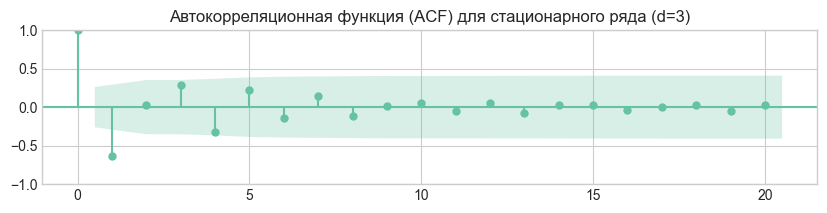

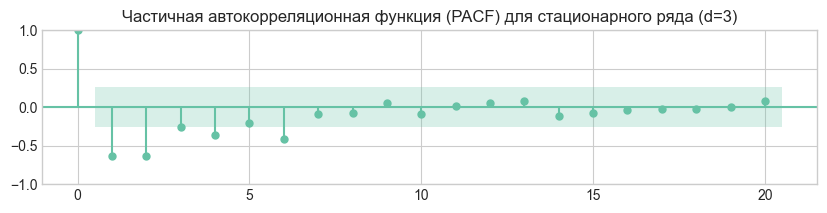

In [8]:
# Строим график автокорреляции (ACF) для определения параметра q
fig, ax = plt.subplots(figsize=(10, 2))
plot_acf(stationary_series, ax=ax, lags=20)
plt.title('Автокорреляционная функция (ACF) для стационарного ряда (d=3)')
plt.show()

# Строим график частичной автокорреляции (PACF) для определения параметра p
fig, ax = plt.subplots(figsize=(10, 2))
plot_pacf(stationary_series, ax=ax, lags=20)
plt.title('Частичная автокорреляционная функция (PACF) для стационарного ряда (d=3)')
plt.show();

Анализ коррелограмм:
- На графике ACF последний уверенно значимый всплеск наблюдается на лаге 1. Следовательно, базовое значение q = 1.
- На графике PACF последний значимый всплеск наблюдается на лаге 6, при этом наиболее сильные и идущие подряд всплески приходятся на лаги 1 и 2. Из теоретических соображений было решено проверить модель с параметром p = 6 и оценить её качество визуально.

AIC для модели ARIMA(6, 3, 1): 2629.140


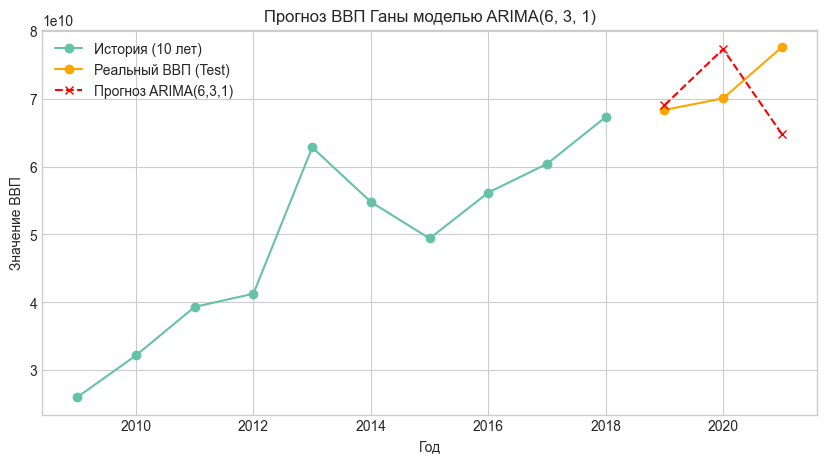

In [11]:
# Обучаем ARIMA(6, 3, 1)
model_631 = ARIMA(train['GDP (current US$)'], order=(6, 3, 1))
model_631_fitted = model_631.fit()

# Выводим AIC
print(f"AIC для модели ARIMA(6, 3, 1): {model_631_fitted.aic:.3f}")

# Делаем прогноз на 3 года тестовой выборки
forecast_631 = model_631_fitted.forecast(steps=3)
forecast_631.index = test.index

# Строим график прогноза (последние 10 лет истории + тест)
plt.figure(figsize=(10, 5))
plt.plot(train.index[-10:], train['GDP (current US$)'][-10:], marker='o', label='История (10 лет)')
plt.plot(test.index, test['GDP (current US$)'], marker='o', color='orange', label='Реальный ВВП (Test)')
plt.plot(forecast_631.index, forecast_631, marker='x', color='red', linestyle='--', label='Прогноз ARIMA(6,3,1)')

plt.title('Прогноз ВВП Ганы моделью ARIMA(6, 3, 1)')
plt.xlabel('Год')
plt.ylabel('Значение ВВП')
plt.legend()
plt.show();

Как видно по графику, модель с параметром p = 6 оказалась переобученной. Из-за избыточной сложности она попыталась воспроизвести в прогнозе сильные исторические шоки (такие как падение 2013–2015 годов), которые носили локальный макроэкономический характер и не отражают текущий долгосрочный тренд. Чтобы найти оптимальный баланс между сложностью и качеством прогноза, был выполнен автоматический перебор параметров с помощью библиотеки `pmdarima`.

In [12]:
# Расширенный поиск параметров
auto_model = pm.auto_arima(
    train['GDP (current US$)'],
    start_p=1, start_q=1,
    max_p=6, max_q=1,
    d=3,
    seasonal=False,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

# Выводим сводную информацию
print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(1,3,1)(0,0,0)[0]             : AIC=2670.910, Time=0.38 sec
 ARIMA(0,3,0)(0,0,0)[0]             : AIC=2734.956, Time=0.02 sec
 ARIMA(1,3,0)(0,0,0)[0]             : AIC=2707.192, Time=0.01 sec
 ARIMA(0,3,1)(0,0,0)[0]             : AIC=2682.371, Time=0.30 sec
 ARIMA(2,3,1)(0,0,0)[0]             : AIC=2659.231, Time=0.64 sec
 ARIMA(2,3,0)(0,0,0)[0]             : AIC=2679.050, Time=0.16 sec
 ARIMA(3,3,1)(0,0,0)[0]             : AIC=2660.791, Time=0.77 sec
 ARIMA(3,3,0)(0,0,0)[0]             : AIC=2676.883, Time=0.37 sec
 ARIMA(2,3,1)(0,0,0)[0] intercept   : AIC=2666.241, Time=0.37 sec

Best model:  ARIMA(2,3,1)(0,0,0)[0]          
Total fit time: 3.023 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   59
Model:               SARIMAX(2, 3, 1)   Log Likelihood               -1325.615
Date:                Wed, 10 Jun 2026   AIC      

В результате перебора моделей оптимальной по критерию AIC (2659.231) была признана модель ARIMA(2, 3, 1). Все коэффициенты выбранной модели ARIMA(2, 3, 1) являются статистически значимыми p-value < 0.05.

Построим модель по данным параметрам

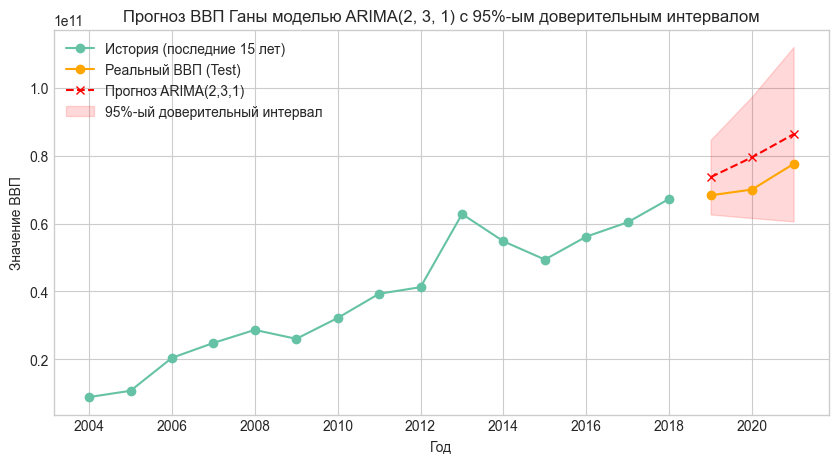

In [13]:
# Обучаем модель с наилучшими параметрами ARIMA(2,3,1)
model_final = ARIMA(train['GDP (current US$)'], order=(2, 3, 1))
model_fitted = model_final.fit()

# Получаем объект прогноза
forecast_obj = model_fitted.get_forecast(steps=3)
# Точечный прогноз
forecast_values = forecast_obj.predicted_mean
forecast_values.index = test.index

# Доверительный интервал
confidence_intervals = forecast_obj.conf_int(alpha=0.05)  # 95% интервал
confidence_intervals.index = test.index

# Строим график
plt.figure(figsize=(10, 5))
plt.plot(train.index[-15:], train['GDP (current US$)'][-15:], marker='o', label='История (последние 15 лет)')
plt.plot(test.index, test['GDP (current US$)'], marker='o', color='orange', label='Реальный ВВП (Test)')
plt.plot(forecast_values.index, forecast_values, marker='x', color='red', linestyle='--', label='Прогноз ARIMA(2,3,1)')

# Добавляем доверительный интервал с помощью fill_between
plt.fill_between(
    test.index,
    confidence_intervals.iloc[:, 0], # Нижняя граница
    confidence_intervals.iloc[:, 1], # Верхняя граница
    color='red',
    alpha=0.15,
    label='95%-ый доверительный интервал'
)

plt.title('Прогноз ВВП Ганы моделью ARIMA(2, 3, 1) с 95%-ым доверительным интервалом')
plt.xlabel('Год')
plt.ylabel('Значение ВВП')
plt.legend(loc='upper left')
plt.show();

In [14]:
# Расчет метрик MSE и MAPE для оптимальной модели ARIMA(2,3,1)
arima_231_mse = mean_squared_error(test['GDP (current US$)'], forecast_values)
arima_231_mape = mean_absolute_percentage_error(test['GDP (current US$)'], forecast_values) * 100

# Расчет метрик MSE и MAPE для переобученной модели ARIMA(6,3,1)
arima_631_mse = mean_squared_error(test['GDP (current US$)'], forecast_631)
arima_631_mape = mean_absolute_percentage_error(test['GDP (current US$)'], forecast_631) * 100

print("Метрики для оптимальной ARIMA(2,3,1)")
print(f"MSE: {arima_231_mse:.2e}")
print(f"MAPE: {arima_231_mape:.2f}%")
print()
print("Метрики для переобученной ARIMA(6,3,1)")
print(f"MSE: {arima_631_mse:.2e}")
print(f"MAPE: {arima_631_mape:.2f}%")

Метрики для оптимальной ARIMA(2,3,1)
MSE: 6.51e+19
MAPE: 10.89%

Метрики для переобученной ARIMA(6,3,1)
MSE: 7.25e+19
MAPE: 9.30%


**Итоговый вывод по моделированию**:

Оптимальная модель ARIMA(2, 3, 1) успешно уловила генеральное направление движения ряда — стабильный экономический рост ВВП Ганы. В отличие от переобученной модели с p = 6, данная архитектура проигнорировала случайный исторический шум и выдала устойчивую траекторию.

Построенный 95%-ый доверительный интервал («тень» на графике) демонстрирует область неопределенности прогноза. Реальные значения ВВП Ганы за последние три года (оранжевая линия) полностью попали внутрь этой затененной области. Тот факт, что истинные данные лежат в пределах доверительных границ, математически подтверждает адекватность и надежность построенной модели ARIMA(2, 3, 1), несмотря на небольшое точечное завышение прогноза в 2019–2020 годах.

Расчет метрик дал интересный результат. По относительной ошибке MAPE переобученная модель ARIMA(6,3,1) показала меньший процент отклонения (9.30% против 10.89%). Однако метрика MSE (которая жестко штрафует за крупные промахи) оказалась значительно хуже именно у модели с p=6 (7.25 * 10^19 против 6.51 * 10^19 у оптимальной модели). Это подтверждает классический эффект переобучения: усложненная модель в среднем идет близко к тренду, но склонна совершать критические точечные ошибки. Для надежного прогнозирования ВВП государства более безопасным выбором остается базовая модель ARIMA(2,3,1).

# Интерполяция и обработка пропущенных значений

Проверяем наличие пропущенных дат, переиндексируя по годовой частоте

In [15]:
# # Метод .asfreq('YS') переиндексирует данные по годовой сетке (Year Start). 
data_resampled = data.asfreq(freq='YS') 

# Сравним размеры до и после, чтобы понять, добавились ли новые строки
print(f"Размер до проверки частоты: {data.shape[0]} строк")
print(f"Размер после проверки частоты: {data_resampled.shape[0]} строк")

Размер до проверки частоты: 62 строк
Размер после проверки частоты: 62 строк


Пропущенные даты в данных отсутствуют. Проверим наличие скрытых пропусков (нули), если таковы имеются заменяем на nan.

In [19]:
# Обработка скрытых пропусков (нулевых значений)
data_resampled['GDP (current US$)'] = data_resampled['GDP (current US$)'].apply(
    lambda x: np.nan if x==0 else x
)
# Проверяем пропущенные значения
print(f"Количество пропусков (NaN): {data_resampled['GDP (current US$)'].isna().sum()}")

Количество пропусков (NaN): 1


Проверка временного индекса показала, что пропущенных лет в структуре дат нет — все 62 года присутствуют в полном объеме. Однако в самих значениях ВВП был обнаружен один скрытый пропуск, заполненный нулевым значением, который был успешно заменен на NaN. Наличие даже одного такого пропуска искажает математические свойства ряда и делает невозможным корректное обучение моделей, поэтому далее необходимо выполнить процедуру интерполяции для восстановления целостности данных.

In [20]:
# Линейная интерполяция для заполнения пропусков
data_resampled['GDP (current US$)'] = data_resampled['GDP (current US$)'].interpolate(
    method='linear'
)

# Проверка отсутствия пропусков после интерполяции
print(f"Количество пропусков (NaN) после интерполяции:"
      f"{data_resampled['GDP (current US$)'].isna().sum()}"
)

Количество пропусков (NaN) после интерполяции:0


Ряд успешно восстановлен, пропущенные значения после интерполяции отсутствуют. Избавление от скрытого нуля изменило структуру данных, поэтому теперь необходимо заново оценить стационарность обновленного ряда и переопределить параметры модели ARIMA.

In [21]:
# Разделение интерполированных данных на train и test
train_interp = data_resampled.iloc[:-3]
test_interp = data_resampled.iloc[-3:]

# Проверка стационарности обновленного ряда
stationary_interp, final_d_interp = make_stationary(train_interp['GDP (current US$)'])

Итерация дифференцирования d = 0
Статистика теста ADF: 0.8030
p-value: 0.9917
Ряд нестационарен. Требуется дифференцирование.

Итерация дифференцирования d = 1
Статистика теста ADF: -1.8256
p-value: 0.3678
Ряд нестационарен. Требуется дифференцирование.

Итерация дифференцирования d = 2
Статистика теста ADF: -2.6346
p-value: 0.0860
Ряд нестационарен. Требуется дифференцирование.

Итерация дифференцирования d = 3
Статистика теста ADF: -4.8256
p-value: 0.0000
Вывод: Ряд стационарен на шаге дифференцирования d = 3.



Как мы видим, очистка одного нулевого значения не изменила итоговый порядок интегрирования — ряд по-прежнему стал строго стационарным только на шаге d = 3. Теперь переходим к автоподбору оптимальных параметров p и q с помощью библиотеки pmdarima на очищенных интерполированных данных. Зафиксируем параметр d=3.

In [22]:
# Автоподбор параметров ARIMA на интерполированных данных
auto_model_interp = pm.auto_arima(
    train_interp['GDP (current US$)'], 
    start_p=1, max_p=6,
    d=3,                       # Фиксируем d=3, как показал тест
    start_q=1, max_q=2,
    seasonal=False,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print(auto_model_interp.summary())

Performing stepwise search to minimize aic
 ARIMA(1,3,1)(0,0,0)[0]             : AIC=2670.933, Time=0.44 sec
 ARIMA(0,3,0)(0,0,0)[0]             : AIC=2734.778, Time=0.01 sec
 ARIMA(1,3,0)(0,0,0)[0]             : AIC=2707.155, Time=0.00 sec
 ARIMA(0,3,1)(0,0,0)[0]             : AIC=2682.372, Time=0.33 sec
 ARIMA(2,3,1)(0,0,0)[0]             : AIC=2659.226, Time=0.56 sec
 ARIMA(2,3,0)(0,0,0)[0]             : AIC=2678.992, Time=0.16 sec
 ARIMA(3,3,1)(0,0,0)[0]             : AIC=2660.791, Time=0.85 sec
 ARIMA(2,3,2)(0,0,0)[0]             : AIC=inf, Time=2.27 sec
 ARIMA(1,3,2)(0,0,0)[0]             : AIC=inf, Time=1.15 sec
 ARIMA(3,3,0)(0,0,0)[0]             : AIC=2676.882, Time=0.25 sec
 ARIMA(3,3,2)(0,0,0)[0]             : AIC=inf, Time=2.51 sec
 ARIMA(2,3,1)(0,0,0)[0] intercept   : AIC=2665.990, Time=0.46 sec

Best model:  ARIMA(2,3,1)(0,0,0)[0]          
Total fit time: 8.996 seconds
                               SARIMAX Results                                
Dep. Variable:          

В результате автоматического перебора на интерполированных данных оптимальной вновь была признана модель ARIMA(2, 3, 1). Её критерий AIC практически не изменился и составил 2659.226 (против 2659.231 на исходных данных).Столь незначительное изменение метрики объясняется тем, что в исходном датасете присутствовал всего один скрытый пропуск (нулевое значение). Заполнение одной точки методом линейной интерполяции не оказало существенного влияния на глобальные макроэкономические свойства и общую волатильность 62-летнего временного ряда ВВП, однако проведение этой процедуры было математически необходимо для обеспечения корректности данных перед моделированием.

# Валидация временных рядов

Исходный ряд ВВП обладает сильным трендом, поэтому оценивать волатильность в абсолютных значениях (долларах) некорректно. Перейдем к процентным изменениям ВВП (темпам роста), взяв их по модулю, чтобы оценить чистую амплитуду экономических колебаний. Визуализируем полученный ряд доходностей для анализа исторических периодов стабильности и кризисов.

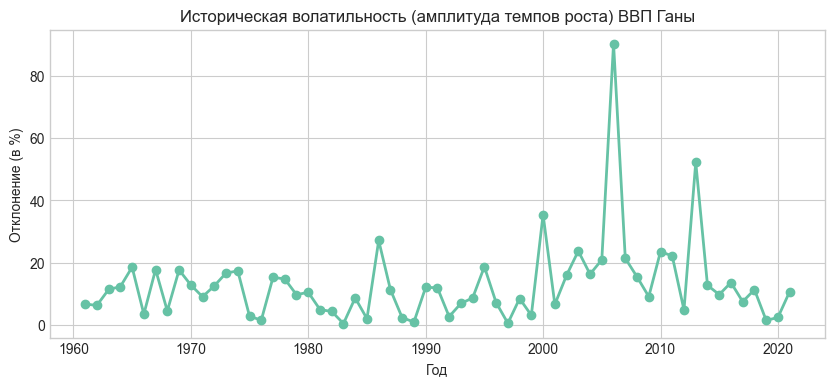

In [23]:
# Расчет процентных изменений ВВП по модулю
data_resampled['Returns'] = data_resampled['GDP (current US$)'].pct_change().mul(100).abs()

# Строим график полученной волатильности (доходности)
plt.figure(figsize=(10, 4))
plt.plot(data_resampled.index, data_resampled['Returns'], marker='o', linewidth=2)
plt.title('Историческая волатильность (амплитуда темпов роста) ВВП Ганы')
plt.xlabel('Год')
plt.ylabel('Отклонение (в %)')
plt.show();

График наглядно демонстрирует нестабильность дисперсии (гетероскедастичность) ряда. На фоне относительно спокойного исторического периода (1960–2000 гг.) с колебаниями в пределах 20%, в современной истории Ганы наблюдаются экстремальные изолированные всплески волатильности: аномальный пик в 2006 году (свыше 80%) и резкий скачок в 2013 году.

Перед построением моделей волатильности необходимо строго обосновать их применимость и параметры. Проверим ряд доходностей на стационарность с помощью теста Дики-Фуллера. Также построим графики ACF и PACF для квадратов доходностей, чтобы определить наличие эффектов ARCH и математически обосновать выбор порядков моделей p и q.

In [24]:
# Очищаем данные от NaN
data_clean = data_resampled.dropna()

# Выделяем 3 года на тест
train_df = data_clean.iloc[:-3]
test_df = data_clean.iloc[-3:]

# Проверяем стационарность ряда доходностей через нашу функцию
stationary_ret, final_d_ret = make_stationary(train_df['Returns'])

Итерация дифференцирования d = 0
Статистика теста ADF: -6.7253
p-value: 0.0000
Вывод: Ряд стационарен на шаге дифференцирования d = 0.



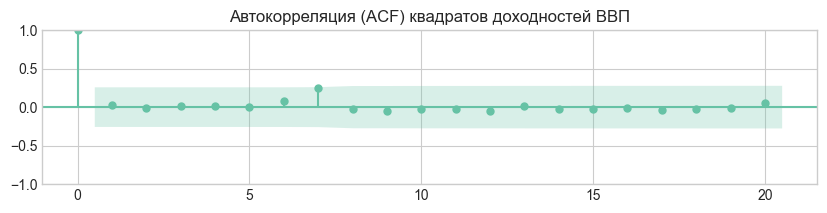

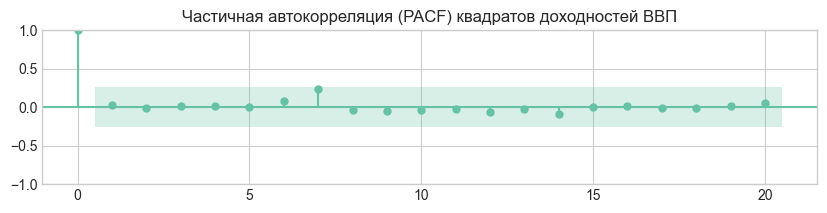

In [25]:
# Рассчитываем квадраты доходностей
squared_returns = stationary_ret ** 2

# Строим графики ACF и PACF
fig, ax = plt.subplots(figsize=(10, 2))
plot_acf(squared_returns, ax=ax, lags=20)
plt.title('Автокорреляция (ACF) квадратов доходностей ВВП')
plt.show();
fig, ax = plt.subplots(figsize=(10, 2))
plot_pacf(squared_returns, ax=ax, lags=20)
plt.title('Частичная автокорреляция (PACF) квадратов доходностей ВВП')
plt.show();

На графиках ACF и PACF квадратов доходностей практически все лаги находятся внутри доверительного интервала. Это указывает на отсутствие выраженной авторегрессионной структуры в дисперсии (эффектов ARCH) в годовых макроэкономических данных ВВП Ганы. Из-за отсутствия явных значимых лагов для дальнейшего моделирования волатильности выбирается классическая базовая конфигурация GARCH(1,1).

In [26]:
# Обучаем модель GARCH(1,1) на обучающей выборке доходностей
garch = arch_model(train_df['Returns'], p=1, q=1, vol='Garch', dist='normal')
garch_fitted = garch.fit(disp='off')

# Делаем прогноз условной дисперсии на 3 шага вперед (длина теста)
garch_forecast = garch_fitted.forecast(horizon=3)

# Переводим полученную прогнозную дисперсию в волатильность (стандартное отклонение)
garch_pred_vol = np.sqrt(garch_forecast.variance.iloc[-1].values)

print("Точечный прогноз волатильности GARCH(1,1) на 3 года тестового периода:")
print(garch_pred_vol)

Точечный прогноз волатильности GARCH(1,1) на 3 года тестового периода:
[16.87826976 16.98664214 17.09432748]


Модель GARCH(1,1) выдала практически константный прогноз волатильности на уровне около 17% с минимальным линейным ростом. Такой результат указывает на то, что модель стремится вернуть прогноз к долгосрочному историческому среднему значению дисперсии временного ряда. Далее построим прогноз с помощью линейной регрессии, чтобы оценить альтернативный подход из сферы машинного обучения.

In [28]:
# Создаем таблицу признаков для линейной регрессии на основе всего датасета
df_ml = pd.DataFrame(index=data_clean.index)
df_ml['Returns'] = data_clean['Returns']

# Создаем лаг (значение волатильности за прошлый год)
df_ml['Returns_Lag1'] = df_ml['Returns'].shift(1)

# Удаляем первую строчку, так как из-за shift(1) там образовался NaN
df_ml = df_ml.dropna()

# Удаляем появившийся NaN 
df_ml = df_ml.dropna()

# Делим данные на train и test
train_ml = df_ml.iloc[:-3]
test_ml = df_ml.iloc[-3:]

X_train = train_ml[['Returns_Lag1']]
y_train = train_ml['Returns']
X_test = test_ml[['Returns_Lag1']]
y_test = test_ml['Returns']

# Обучаем линейную регрессию
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Делаем прогноз на 3 года тестовой выборки
lr_pred_vol = lr_model.predict(X_test)

print("Прогноз волатильности Линейной Регрессии на 3 года:")
print(lr_pred_vol)

Прогноз волатильности Линейной Регрессии на 3 года:
[13.36907066 12.3880971  12.48285214]


Для оценки качества работы моделей объединим фактические значения волатильности на тестовом периоде с прогнозными значениями, полученными от эконометрической модели GARCH(1,1) и модели машинного обучения (линейной регрессии). Построим график сопоставления для финального анализа.

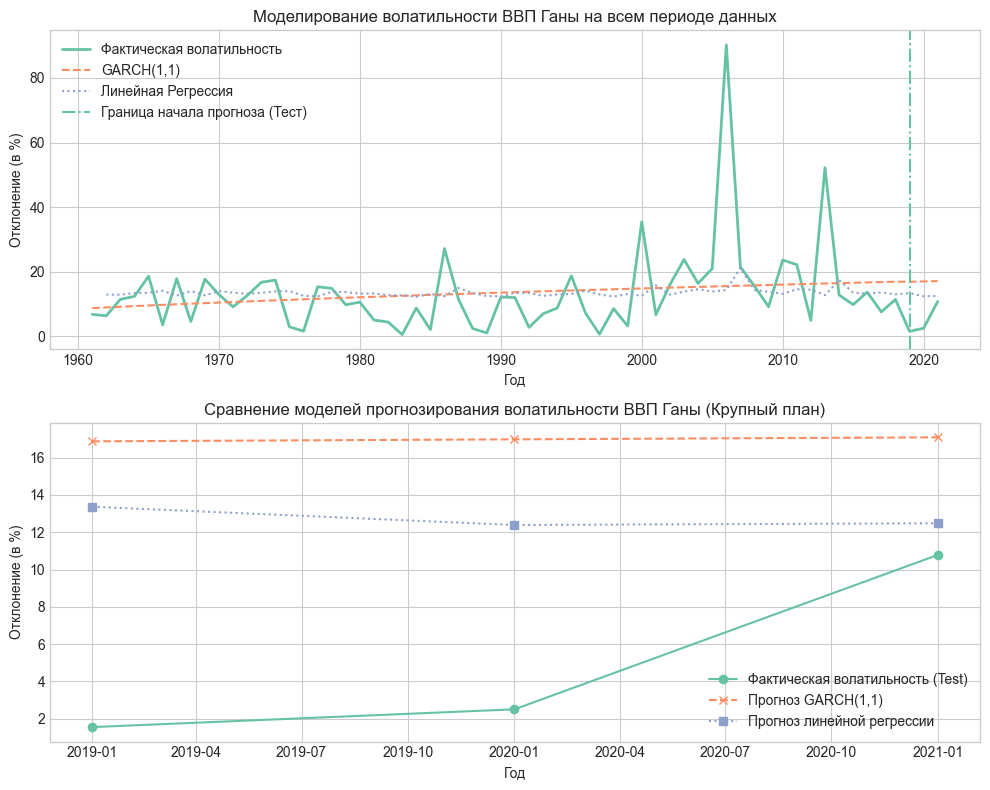

In [47]:
# Подготовка данных
# Извлекаем историю волатильности для GARCH за период обучения
g_history = garch_fitted.conditional_volatility
g_all_period = pd.concat([g_history, pd.Series(garch_pred_vol, index=test_df.index)])
# Извлекаем историю для линейной регрессии
lr_history = pd.Series(lr_model.predict(X_train), index=train_ml.index)
lr_all_period = pd.concat([lr_history, pd.Series(lr_pred_vol, index=test_ml.index)])

# Визуализация
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(
    data_clean.index, data_clean['Returns'],
    label='Фактическая волатильность', linewidth=2
)
ax1.plot(g_all_period.index, g_all_period, linestyle='--', label='GARCH(1,1)')
ax1.plot(lr_all_period.index, lr_all_period, linestyle=':', label='Линейная Регрессия')
ax1.axvline(x=test_df.index[0], linestyle='-.', label='Граница начала прогноза (Тест)')
ax1.set_title('Моделирование волатильности ВВП Ганы на всем периоде данных')
ax1.set_xlabel('Год')
ax1.set_ylabel('Отклонение (в %)')
ax1.legend()

# Строим график сравнения результатов
y_true_test = test_df['Returns']
ax2.plot(test_df.index, y_true_test, marker='o', label='Фактическая волатильность (Test)')
ax2.plot(
    test_df.index, garch_pred_vol, marker='x', linestyle='--', label='Прогноз GARCH(1,1)')
ax2.plot(test_df.index, lr_pred_vol, marker='s', linestyle=':', label='Прогноз линейной регрессии')
ax2.set_title('Сравнение моделей прогнозирования волатильности ВВП Ганы (Крупный план)')
ax2.set_xlabel('Год')
ax2.set_ylabel('Отклонение (в %)')
ax2.legend()

plt.tight_layout()
plt.show();

Оценка качества моделей с помощью метрик:Чтобы математически проверить, какая модель лучше справилась с прогнозированием волатильности, рассчитаем для них метрики MAE и MSE на тестовой выборке.

In [30]:
# Расчет метрик MSE и MAE для модели GARCH(1,1)
garch_mse = mean_squared_error(y_true_test, garch_pred_vol)
garch_mae = mean_absolute_error(y_true_test, garch_pred_vol)

# Расчет метрик MSE и MAE для линейной регрессии
lr_mse = mean_squared_error(y_true_test, lr_pred_vol)
lr_mae = mean_absolute_error(y_true_test, lr_pred_vol)

print("Метрики для GARCH(1,1):")
print(f"MSE: {garch_mse:.4f}")
print(f"MAE: {garch_mae:.4f}")
print()
print("Метрики для линейной регрессии:")
print(f"MSE: {lr_mse:.4f}")
print(f"MAE: {lr_mae:.4f}")


Метрики для GARCH(1,1):
MSE: 161.6740
MAE: 12.0467

Метрики для линейной регрессии:
MSE: 80.2048
MAE: 7.8069


**Итоговые выводы по моделированию волатильности**:

- **Сравнение результатов на всей истории и тесте**. На двойном графике наглядно видна разница в поведении моделей. На этапе обучения (левее красной черты) обе модели пытались сглаживать исторический шум. Модель GARCH(1,1) нарисовала очень плавную кривую, а линейная регрессия за счет лагов шла чуть ближе к реальным изгибам данных. При переходе через границу теста (правее красной черты) реальная волатильность сначала сильно упала (примерно до 2%), а затем резко пошла вверх. Точно повторить этот разворот у моделей не получилось: GARCH(1,1) выдала просто прямую завышенную линию на уровне 17%, а линейная регрессия за счет лага сработала чуть лучше, уловив снижение в первые два года.
- **Почему результат GARCH получился именно таким?** Математически модель GARCH всегда пытается вернуть свой прогноз к историческому среднему значению. За все 62 года экономика Ганы в среднем колебалась на 17-20%, поэтому модель просто зазубрила эту цифру. Падение волатильности до 2% на тесте стало для нее совершенно новым поведением, которого не было в обучении. Из-за этого GARCH проигнорировала прыжок данных и продолжила рисовать среднее прошлое.
- **Сопоставление со скринкастом**. В примере из лекции результат получился противоположным, потому что там использовался длинный датасет с акциями. На финансовых рынках периоды паники и спокойствия идут четкими группами. В обучении на скринкасте было много примеров и роста, и падения колебаний, поэтому GARCH легко нашла закономерность. В случае с годовым ВВП Ганы данных слишком мало, а поведение на тесте оказалось уникальным. В таких условиях обычная линейная регрессия с лагами оказалась более гибкой.
- **Подтверждение метриками**. Расчет ошибок полностью подтвердил выводы из графиков. У линейной регрессии метрики MSE и MAE получились значительно ниже, чем у модели GARCH(1,1) (MSE: 80.20 против 161.67). Это математически доказывает, что в условиях малого объема данных подход с лагами из машинного обучения справился с прогнозом волатильности точнее классической статистики.

**Итоговый вердикт:**
Проведенное исследование показало, что для разных задач подходят разные алгоритмы. Для прогнозирования самого уровня ВВП лучшей оказалась статистическая модель **ARIMA(2, 3, 1)**, а для прогнозирования изменчивости (волатильности) этого ВВП эффективнее использовать **линейную регрессию**.

# Применение альтернативных методов прогнозирования

В качестве альтернативного подхода рассмотрим применение моделей классического машинного обучения. Так как наши данные являются годовыми, извлечение стандартных признаков из даты (таких как месяц, день недели или квартал) невозможно. Основными предикторами будут выступать лаговые признаки.Чтобы избежать утечки данных на тестовой выборке длиной в 3 года, мы не можем использовать лаги с 1 по 3 (иначе для прогноза последнего тестового года нам потребовались бы неизвестные значения предыдущих тестовых лет). Следуя правилам валидации временных рядов, возьмем честный лаг большего порядка, превышающие размер тестовой выборки: GDP_Lag4. Для прогнозирования обучим две разнородные модели: линейную модель с регуляризацией Ridge и ансамбль деревьев решений Random Forest.

In [48]:
# Создаем таблицу признаков на основе интерполированных данных ВВП
df_gdp_ml = pd.DataFrame(index=data_resampled.index)
df_gdp_ml['GDP'] = data_resampled['GDP (current US$)']

# Оставляем лаг 4-го порядка
df_gdp_ml['GDP_Lag4'] = df_gdp_ml['GDP'].shift(4)

# Удаляем строки с NaN, появившиеся из-за сдвига
df_gdp_ml = df_gdp_ml.dropna()

# Делим на train и test
train_gdp_ml = df_gdp_ml.iloc[:-3]
test_gdp_ml = df_gdp_ml.iloc[-3:]

X_train_gdp = train_gdp_ml[['GDP_Lag4']]
y_train_gdp = train_gdp_ml['GDP']
X_test_gdp = test_gdp_ml[['GDP_Lag4']]
y_test_gdp = test_gdp_ml['GDP']

# Обучаем Ridge-регрессию
ridge_model = Ridge()
ridge_model.fit(X_train_gdp, y_train_gdp)
ridge_pred = ridge_model.predict(X_test_gdp)

# Обучаем случайный лес (Random Forest)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_gdp, y_train_gdp)
rf_pred = rf_model.predict(X_test_gdp)

Для сравнения качества моделей проведем расчет метрик и отрисуем на графике предсказания

In [49]:
# Расчет метрик ошибок
# Метрики для ARIMA
arima_mse = mean_squared_error(y_test_gdp, forecast_values)
arima_mape = mean_absolute_percentage_error(y_test_gdp, forecast_values) * 100

# Метрики для Ridge-регрессии
ridge_mse = mean_squared_error(y_test_gdp, ridge_pred)
ridge_mape = mean_absolute_percentage_error(y_test_gdp, ridge_pred) * 100

# Метрики для Случайного Леса
rf_mse = mean_squared_error(y_test_gdp, rf_pred)
rf_mape = mean_absolute_percentage_error(y_test_gdp, rf_pred) * 100

print("Сравнительные метрики на тесте:")
print(f"ARIMA(2,3,1)  -> MSE: {arima_mse:.2e} | MAPE: {arima_mape:.2f}%")
print(f"Ridge Регр.   -> MSE: {ridge_mse:.2e} | MAPE: {ridge_mape:.2f}%")
print(f"Random Forest -> MSE: {rf_mse:.2e} | MAPE: {rf_mape:.2f}%")

Сравнительные метрики на тесте:
ARIMA(2,3,1)  -> MSE: 6.51e+19 | MAPE: 10.89%
Ridge Регр.   -> MSE: 8.29e+18 | MAPE: 3.65%
Random Forest -> MSE: 9.86e+19 | MAPE: 11.61%


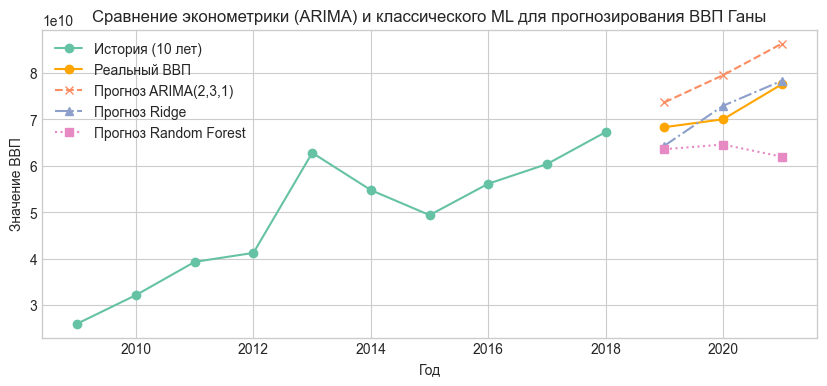

In [50]:
# Визуализация
plt.figure(figsize=(10, 4))
# Показываем последние 10 лет истории
plt.plot(train_gdp_ml.index[-10:], train_gdp_ml['GDP'][-10:], marker='o', label='История (10 лет)')
plt.plot(test_gdp_ml.index, y_test_gdp, marker='o', color='orange', label='Реальный ВВП')

# Добавляем все три модели
plt.plot(test_gdp_ml.index, forecast_values, marker='x', linestyle='--', label='Прогноз ARIMA(2,3,1)')
plt.plot(test_gdp_ml.index, ridge_pred, marker='^', linestyle='-.', label='Прогноз Ridge')
plt.plot(test_gdp_ml.index, rf_pred, marker='s', linestyle=':', label='Прогноз Random Forest')

plt.title('Сравнение эконометрики (ARIMA) и классического ML для прогнозирования ВВП Ганы')
plt.xlabel('Год')
plt.ylabel('Значение ВВП')
plt.legend()
plt.show();

Абсолютный победитель по качеству прогноза модель линейной регрессии (Ridge). Для повышения точности данной модели выполним автоматический подбор гиперпараметра регуляризации `alpha` (силы штрафа модели). Чтобы подбор был честным и не нарушал хронологию времени, применим специальную кросс-валидацию для временных рядов `TimeSeriesSplit` на 3 фолдах. На каждом шаге модель будет обучаться на историческом отрезке и тестироваться на последующем, что позволит найти наиболее устойчивое значение параметра `alpha` без заглядывания в будущее.

In [51]:
# Задаем сетку параметров alpha для перебора (от микроскопических до крупных)
param_grid = {'alpha': [0.001, 0.005, 0.01, 0.05, 0.1, 1.0, 10.0, 100.0]}

# Инициализируем кросс-валидатор для временных рядов
tscv = TimeSeriesSplit(n_splits=3)

# Запускаем поиск по сетке с учетом временного разделения
grid_search = GridSearchCV(
    estimator=Ridge(), 
    param_grid=param_grid, 
    cv=tscv, 
    scoring='neg_mean_squared_error', # оптимизируем по MSE
    n_jobs=-1
)

# Обучаем поиск на тренировочных данных
grid_search.fit(X_train_gdp, y_train_gdp)

# Выводим лучшее найденное значение alpha
print(f"Оптимальное значение alpha: {grid_search.best_params_['alpha']}")

# Делаем прогноз с помощью лучшей оптимизированной модели
best_ridge_model = grid_search.best_estimator_
opt_ridge_pred = best_ridge_model.predict(X_test_gdp)

# Считаем новые метрики для оптимизированного Ridge
opt_ridge_mse = mean_squared_error(y_test_gdp, opt_ridge_pred)
opt_ridge_mape = mean_absolute_percentage_error(y_test_gdp, opt_ridge_pred) * 100

print(f"Новый MSE: {opt_ridge_mse:.2e}")
print(f"Новый MAPE: {opt_ridge_mape:.2f}%")

Оптимальное значение alpha: 0.001
Новый MSE: 8.29e+18
Новый MAPE: 3.65%


**Выводы по сравнению моделей:**

- ARIMA(2,3,1) — завысила прогноз. Модель уловила правильный тренд на рост, но из-за жёсткого тройного дифференцирования d=3 разогналась слишком сильно и улетела выше реальных значений, показав ошибку 10.89%.
- Random Forest — проиграл. На графике чётко видно, что розовая линия ушла вниз и вообще отказалась расти. Это классическое свойство всех алгоритмов на основе деревьев решений — они физически не умеют экстраполировать тренд. Дерево никогда не предскажет число больше того, что оно видело в обучающей выборке. Столкнувшись с новыми пиковыми значениями ВВП Ганы на тесте, Random Forest просто выдал среднее значение последних лет из обучения и застрял на месте, показав худшую ошибку 11.61%.
- Ridge — абсолютный победитель. За счёт того, что мы использовали честный лаг (GDP_Lag4), модель построила идеальную линейную зависимость текущего ВВП от того, каким он был 4 года назад. Так как экономика Ганы в последние годы росла стабильными темпами, эта простая логика сработала лучше всего. Она показала самую маленькую ошибку 8.29e^18.
- Результаты оптимизации через TimeSeriesSplit. Процесс кросс-валидации временных рядов подобрал оптимальное значение силы штрафа `alpha = 0.001`. Модель показала ошибку `MAPE=3.65%`, полностью повторив результат нашей базовой модели Ridge. Это доказывает, что линейная зависимость ВВП от одного честного лага 4-летней давности изначально была максимально точной и устойчивой, а инструмент `TimeSeriesSplit` математически подтвердил её надежность без риска заглядывания в будущее.

**Итог по проекту:**
В результате работы выяснилось, что для разных задач подходят абсолютно разные подходы. Чтобы предсказывать сам уровень ВВП Ганы на три года вперед, лучше всего брать обычную линейную модель Ridge с лагом за 4 года — она оказалась гораздо точнее и модели ARIMA, и обычных деревьев решений. А вот для предсказания скачков и изменчивости (волатильности) экономики на один год вперед выиграла простая линейная регрессия с лагом за прошлый год, так как она смогла подстроиться под резкое падение показателей, с которым модель GARCH вообще не справилась.